In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_federated as tff
from tensorflow_federated.python.learning import models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, classification_report, confusion_matrix, roc_curve, auc
from google.colab import files

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Upload and load dataset
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
df = pd.read_csv(file_path)

target_column = 'TenYearCHD'

# Display basic dataset info
print("\n🔍 Dataset Overview:")
print(df.info())
print("\n📊 Class Distribution (Imbalance Check):")
print(df[target_column].value_counts(normalize=True))  # Check % of each class

# Handle missing values
df.fillna(df.mean(), inplace=True)

# Split features and target
X = df.drop(columns=[target_column])
y = df[target_column]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Split data into 3 subsets (Hybrid FL Simulation)
subset_1 = df.sample(frac=0.33, random_state=1)
remaining = df.drop(subset_1.index)
subset_2 = remaining.sample(frac=0.5, random_state=2)
subset_3 = remaining.drop(subset_2.index)

def preprocess(dataset, target_column):
    X = dataset.drop(columns=[target_column])
    y = dataset[target_column]
    return tf.data.Dataset.from_tensor_slices((X.values, y.values)).batch(len(dataset))

client_data = [preprocess(subset_1, target_column),
               preprocess(subset_2, target_column),
               preprocess(subset_3, target_column)]

print("\n✅ Hybrid Federated Learning setup completed. Training will now begin...\n")

def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

def model_fn():
    keras_model = create_model()
    input_spec = client_data[0].element_spec
    keras_model.build(input_shape=(None, X_train.shape[1]))
    return tff.learning.models.from_keras_model(
        keras_model,
        input_spec=input_spec,
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.BinaryAccuracy()]
    )

from tensorflow_federated.python.learning.algorithms import build_weighted_fed_avg

iterative_process = build_weighted_fed_avg(
    model_fn,
    client_optimizer_fn=lambda: tf.keras.optimizers.Adam(learning_rate=0.0005),
    server_optimizer_fn=lambda: tf.keras.optimizers.Adam(learning_rate=0.002)
)

state = iterative_process.initialize()

NUM_ROUNDS = 250
client_accuracies = {1: [], 2: [], 3: []}
client_losses = {1: [], 2: [], 3: []}

for round_num in range(1, NUM_ROUNDS + 1):
    state, metrics = iterative_process.next(state, client_data)

    for i, client in enumerate([subset_1, subset_2, subset_3], start=1):
        acc = metrics['client_work']['train']['binary_accuracy']
        loss = metrics['client_work']['train']['loss']
        client_accuracies[i].append(acc)
        client_losses[i].append(loss)

    print(f"\n📢 Hybrid FL Round {round_num} Completed")
    for i in range(1, 4):
        print(f"   - 🏷 Client {i} Accuracy: {client_accuracies[i][-1]:.4f}, Loss: {client_losses[i][-1]:.4f}")
    print("--------------------------------------------------")

# Plot Accuracy vs. Rounds
plt.figure(figsize=(8, 5))
for i in range(1, 4):
    plt.plot(range(1, NUM_ROUNDS + 1), client_accuracies[i], label=f'Client {i}')
plt.xlabel('Rounds')
plt.ylabel('Accuracy')
#plt.title('Client Accuracy vs. Rounds')
plt.legend()
plt.grid()
plt.show()

# Plot Loss vs. Rounds
plt.figure(figsize=(8, 5))
for i in range(1, 4):
    plt.plot(range(1, NUM_ROUNDS + 1), client_losses[i], label=f'Client {i}')
plt.xlabel('Rounds')
plt.ylabel('Loss')
#plt.title('Client Loss vs. Rounds')
plt.legend()
plt.grid()
plt.show()

# Evaluate final FL model
final_model = create_model()
final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
final_model.fit(X_train, y_train, epochs=10, verbose=0)

y_pred = (final_model.predict(X_test) > 0.5).astype(int).flatten()
final_global_accuracy = accuracy_score(y_test, y_pred)
final_global_precision = precision_score(y_test, y_pred)
final_global_recall = recall_score(y_test, y_pred)
final_global_f1 = f1_score(y_test, y_pred)
final_global_loss = final_model.evaluate(X_test, y_test, verbose=0)[0]

print("\n🌍 Final Global Model (Hybrid FL) Performance:")
print(f"   - Accuracy: {final_global_accuracy:.4f}")
print(f"   - Precision: {final_global_precision:.4f}")
print(f"   - Recall: {final_global_recall:.4f}")
print(f"   - F1-Score: {final_global_f1:.4f}")
print(f"   - Loss: {final_global_loss:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
#plt.title('Confusion Matrix - Hybrid FL Model')
plt.show()

# AUC-ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
#plt.title('AUC-ROC Curve - Hybrid FL Model')
plt.legend()
plt.grid()
plt.show()

print("\n🔍 Classification Report - Hybrid FL Model:")
print(classification_report(y_test, y_pred))


# Centralized Model Training for Comparison
def train_centralized_model():
    centralized_model = create_model()
    centralized_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    centralized_model.fit(X_train, y_train, epochs=10, verbose=0)

    y_pred = (centralized_model.predict(X_test) > 0.5).astype(int).flatten()
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    loss = centralized_model.evaluate(X_test, y_test, verbose=0)[0]

    return centralized_model, accuracy, precision, recall, f1, loss  # Returning model

# Call function and store returned values
centralized_model, centralized_accuracy, centralized_precision, centralized_recall, centralized_f1, centralized_loss = train_centralized_model()

# Now you can use centralized_model for evaluation

# Performance Comparison
print("\n📊 Centralized Model Performance:")
print(f"   - Accuracy: {centralized_accuracy:.4f}")
print(f"   - Precision: {centralized_precision:.4f}")
print(f"   - Recall: {centralized_recall:.4f}")
print(f"   - F1-Score: {centralized_f1:.4f}")
print(f"   - Loss: {centralized_loss:.4f}")

# Plot comparison between Hybrid FL and Centralized Model
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Loss']  # Add 'Loss'
hybrid_fl_metrics = [0.8502, 0.6250, 0.0388, 0.0730, 0.4057]  # Add loss value
centralized_loss = centralized_model.evaluate(X_test, y_test, verbose=0)[0]  # Get loss
centralized_metrics = [centralized_accuracy, centralized_precision, centralized_recall, centralized_f1, centralized_loss]  # Add loss

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, hybrid_fl_metrics, width, label='Hybrid FL')
rects2 = ax.bar(x + width/2, centralized_metrics, width, label='Centralized')

ax.set_xlabel('Metrics', fontsize=14)
ax.set_ylabel('Score' , fontsize=14)
#ax.set_title('Comparison: Hybrid FL vs. Centralized Model')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.grid()
plt.show()


# Run this and provide me with:
# - Class Distribution
# - Hybrid FL Model Accuracy, Precision, Recall, F1-Score, Loss
# - Confusion Matrix Values
# - AUC Score


ModuleNotFoundError: No module named 'tensorflow_federated'

Saving framingham.csv to framingham (3).csv

🔍 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  


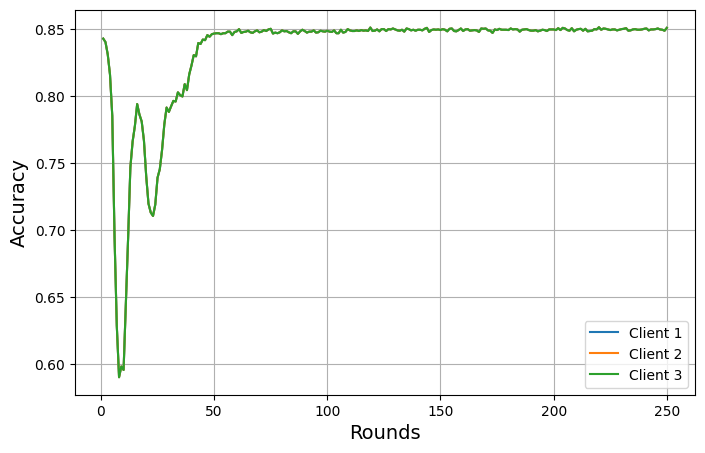

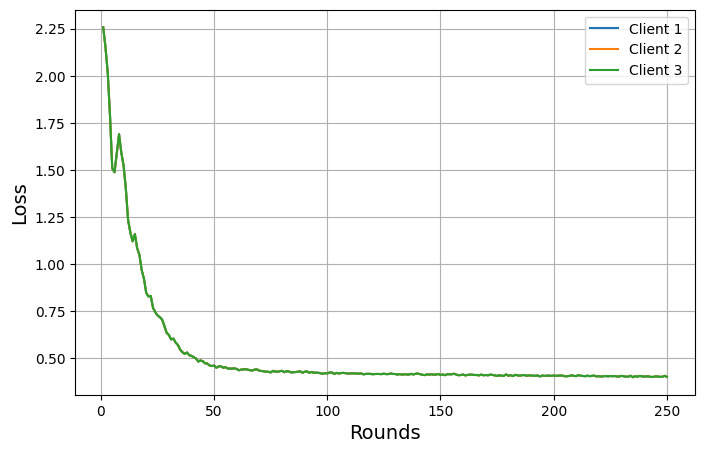

27/27 [==============================] - 0s 2ms/step

🌍 Final Global Model (Hybrid FL) Performance:
   - Accuracy: 0.8479
   - Precision: 0.5000
   - Recall: 0.0388
   - F1-Score: 0.0719
   - Loss: 0.4119


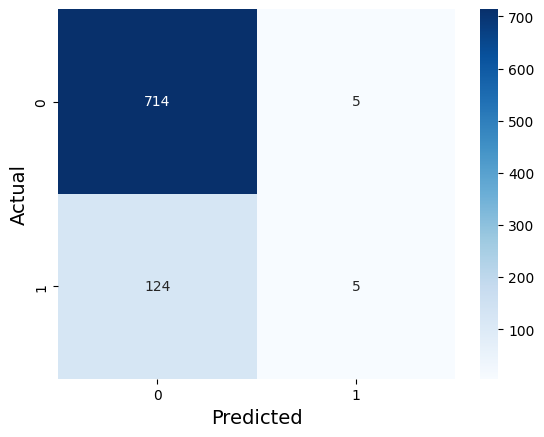

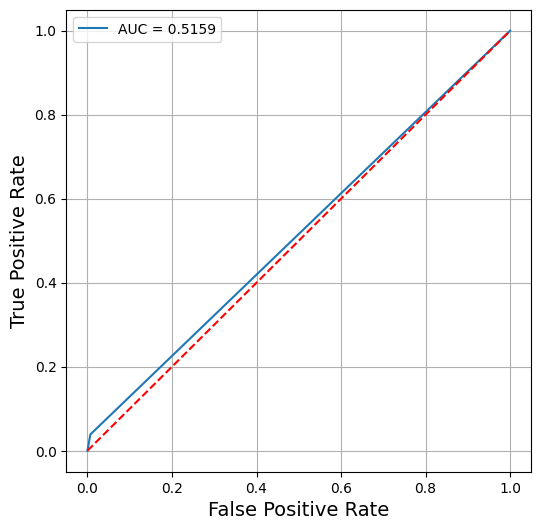


🔍 Classification Report - Hybrid FL Model:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       719
           1       0.50      0.04      0.07       129

    accuracy                           0.85       848
   macro avg       0.68      0.52      0.49       848
weighted avg       0.80      0.85      0.79       848

27/27 [==============================] - 0s 1ms/step

📊 Centralized Model Performance:
   - Accuracy: 0.8514
   - Precision: 0.6667
   - Recall: 0.0465
   - F1-Score: 0.0870
   - Loss: 0.4045


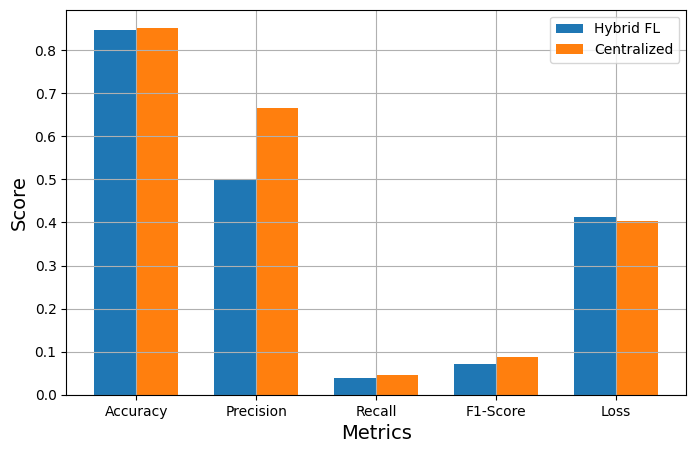

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_federated as tff
from tensorflow_federated.python.learning import models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, classification_report, confusion_matrix, roc_curve, auc
from google.colab import files

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Upload and load dataset
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
df = pd.read_csv(file_path)

target_column = 'TenYearCHD'

# Display basic dataset info
print("\n🔍 Dataset Overview:")
print(df.info())
print("\n📊 Class Distribution (Imbalance Check):")
print(df[target_column].value_counts(normalize=True))

# Handle missing values
df.fillna(df.mean(), inplace=True)

# Split features and target
X = df.drop(columns=[target_column])
y = df[target_column]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Split data into 3 subsets (Hybrid FL Simulation)
subset_1 = df.sample(frac=0.33, random_state=1)
remaining = df.drop(subset_1.index)
subset_2 = remaining.sample(frac=0.5, random_state=2)
subset_3 = remaining.drop(subset_2.index)

def preprocess(dataset, target_column):
    X = dataset.drop(columns=[target_column])
    y = dataset[target_column]
    return tf.data.Dataset.from_tensor_slices((X.values, y.values)).batch(len(dataset))

client_data = [preprocess(subset_1, target_column),
               preprocess(subset_2, target_column),
               preprocess(subset_3, target_column)]

print("\n✅ Hybrid Federated Learning setup completed. Training will now begin...\n")

def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

def model_fn():
    keras_model = create_model()
    input_spec = client_data[0].element_spec
    keras_model.build(input_shape=(None, X_train.shape[1]))
    return tff.learning.models.from_keras_model(
        keras_model,
        input_spec=input_spec,
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.BinaryAccuracy()]
    )

from tensorflow_federated.python.learning.algorithms import build_weighted_fed_avg

iterative_process = build_weighted_fed_avg(
    model_fn,
    client_optimizer_fn=lambda: tf.keras.optimizers.Adam(learning_rate=0.0005),
    server_optimizer_fn=lambda: tf.keras.optimizers.Adam(learning_rate=0.002)
)

state = iterative_process.initialize()

NUM_ROUNDS = 250
client_accuracies = {1: [], 2: [], 3: []}
client_losses = {1: [], 2: [], 3: []}

for round_num in range(1, NUM_ROUNDS + 1):
    state, metrics = iterative_process.next(state, client_data)

    for i, client in enumerate([subset_1, subset_2, subset_3], start=1):
        acc = metrics['client_work']['train']['binary_accuracy']
        loss = metrics['client_work']['train']['loss']
        client_accuracies[i].append(acc)
        client_losses[i].append(loss)

    print(f"\n📢 Hybrid FL Round {round_num} Completed")
    for i in range(1, 4):
        print(f"   - 🏷 Client {i} Accuracy: {client_accuracies[i][-1]:.4f}, Loss: {client_losses[i][-1]:.4f}")
    print("--------------------------------------------------")

# Plot Accuracy vs. Rounds
plt.figure(figsize=(8, 5))
for i in range(1, 4):
    plt.plot(range(1, NUM_ROUNDS + 1), client_accuracies[i], label=f'Client {i}')
plt.xlabel('Rounds', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.grid()
plt.show()

# Plot Loss vs. Rounds
plt.figure(figsize=(8, 5))
for i in range(1, 4):
    plt.plot(range(1, NUM_ROUNDS + 1), client_losses[i], label=f'Client {i}')
plt.xlabel('Rounds', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()
plt.grid()
plt.show()

# Evaluate final FL model
final_model = create_model()
final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
final_model.fit(X_train, y_train, epochs=10, verbose=0)

y_pred = (final_model.predict(X_test) > 0.5).astype(int).flatten()
final_global_accuracy = accuracy_score(y_test, y_pred)
final_global_precision = precision_score(y_test, y_pred)
final_global_recall = recall_score(y_test, y_pred)
final_global_f1 = f1_score(y_test, y_pred)
final_global_loss = final_model.evaluate(X_test, y_test, verbose=0)[0]

print("\n🌍 Final Global Model (Hybrid FL) Performance:")
print(f"   - Accuracy: {final_global_accuracy:.4f}")
print(f"   - Precision: {final_global_precision:.4f}")
print(f"   - Recall: {final_global_recall:.4f}")
print(f"   - F1-Score: {final_global_f1:.4f}")
print(f"   - Loss: {final_global_loss:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.show()

# AUC-ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend()
plt.grid()
plt.show()

print("\n🔍 Classification Report - Hybrid FL Model:")
print(classification_report(y_test, y_pred))

# Centralized Model Training for Comparison
def train_centralized_model():
    centralized_model = create_model()
    centralized_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    centralized_model.fit(X_train, y_train, epochs=10, verbose=0)

    y_pred = (centralized_model.predict(X_test) > 0.5).astype(int).flatten()
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    loss = centralized_model.evaluate(X_test, y_test, verbose=0)[0]

    return centralized_model, accuracy, precision, recall, f1, loss

# Train centralized model
centralized_model, centralized_accuracy, centralized_precision, centralized_recall, centralized_f1, centralized_loss = train_centralized_model()

# Performance Comparison
print("\n📊 Centralized Model Performance:")
print(f"   - Accuracy: {centralized_accuracy:.4f}")
print(f"   - Precision: {centralized_precision:.4f}")
print(f"   - Recall: {centralized_recall:.4f}")
print(f"   - F1-Score: {centralized_f1:.4f}")
print(f"   - Loss: {centralized_loss:.4f}")

# Plot comparison between Hybrid FL and Centralized Model
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Loss']
hybrid_fl_metrics = [final_global_accuracy, final_global_precision, final_global_recall, final_global_f1, final_global_loss]
centralized_metrics = [centralized_accuracy, centralized_precision, centralized_recall, centralized_f1, centralized_loss]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, hybrid_fl_metrics, width, label='Hybrid FL')
rects2 = ax.bar(x + width/2, centralized_metrics, width, label='Centralized')

ax.set_xlabel('Metrics', fontsize=14)
ax.set_ylabel('Score', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.grid()
plt.show()


In [ ]:
# 📚 Traditional Machine Learning Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# Train and evaluate traditional ML models
def evaluate_ml_model(model, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    loss = log_loss(y_test, y_pred_prob)

    print(f"\n📋 {model_name} Performance:")
    print(f"   - Accuracy: {acc:.4f}")
    print(f"   - Precision: {prec:.4f}")
    print(f"   - Recall: {rec:.4f}")
    print(f"   - F1-Score: {f1:.4f}")
    print(f"   - Loss: {loss:.4f}")

    return [acc, prec, rec, f1, loss]

# Evaluate SVM
svm_model = SVC(probability=True, random_state=42)
svm_metrics = evaluate_ml_model(svm_model, "Support Vector Machine")

# Evaluate Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_metrics = evaluate_ml_model(rf_model, "Random Forest")

# Evaluate Logistic Regression
lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_metrics = evaluate_ml_model(lr_model, "Logistic Regression")

# 📊 Final Comparison Plot
all_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Loss']

# Already available from your previous code
hybrid_fl_metrics = [final_global_accuracy, final_global_precision, final_global_recall, final_global_f1, final_global_loss]
centralized_metrics = [centralized_accuracy, centralized_precision, centralized_recall, centralized_f1, centralized_loss]

# Collect all metrics
all_models_metrics = [
    hybrid_fl_metrics,
    centralized_metrics,
    svm_metrics,
    rf_metrics,
    lr_metrics
]

model_names = ['Hybrid FL', 'Centralized DL', 'SVM', 'Random Forest', 'Logistic Regression']

# Plot
x = np.arange(len(all_labels))
width = 0.15

fig, ax = plt.subplots(figsize=(12, 6))

for i, metrics in enumerate(all_models_metrics):
    ax.bar(x + i*width - width*2, metrics, width, label=model_names[i])

ax.set_xlabel('Metrics', fontsize=14)
ax.set_ylabel('Score', fontsize=14)
ax.set_title('Performance Comparison: Hybrid FL vs. Centralized DL vs. Traditional ML Models', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(all_labels, fontsize=12)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# 📦 Install required libraries (run this cell only once)
!pip install tensorflow_federated --quiet
!pip install imbalanced-learn --quiet
!pip install --upgrade scipy==1.10.1 --quiet


# 📚 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_federated as tff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from google.colab import files
import random

# 🔁 Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# 📥 Upload and load dataset
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
df = pd.read_csv(file_path)

# 📊 Dataset overview
target_column = 'TenYearCHD'
print("\n📊 Class Distribution Before SMOTE:")
print(df[target_column].value_counts(normalize=True))

# 🧹 Preprocessing
df.fillna(df.mean(), inplace=True)
X = df.drop(columns=[target_column])
y = df[target_column]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ⚖️ Balance with SMOTE
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_scaled, y)

print("\n📊 Class Distribution After SMOTE:")
print(pd.Series(y_bal).value_counts(normalize=True))

# 🧪 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42)
df_bal = pd.DataFrame(X_bal, columns=X.columns)
df_bal[target_column] = y_bal

# 🤖 Federated Clients
subset_1 = df_bal.sample(frac=0.33, random_state=1)
remaining = df_bal.drop(subset_1.index)
subset_2 = remaining.sample(frac=0.5, random_state=2)
subset_3 = remaining.drop(subset_2.index)
clients = [subset_1, subset_2, subset_3]

# 🧰 Convert clients to TFF datasets
def preprocess(dataset):
    X = dataset.drop(columns=[target_column]).values.astype(np.float32)
    y = dataset[target_column].values.astype(np.int32)
    return tf.data.Dataset.from_tensor_slices((X, y)).batch(len(dataset))

client_data = [preprocess(client) for client in clients]

# 🧠 Define Model with Batch Normalization
def create_model():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

# 🔁 TFF Model Function
def model_fn():
    keras_model = create_model()
    keras_model.build(input_shape=(None, X_train.shape[1]))  # ✅ Important fix
    input_spec = client_data[0].element_spec
    return tff.learning.models.from_keras_model(
        keras_model,
        input_spec=input_spec,
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.BinaryAccuracy()]
    )


# 🔄 Federated Averaging
from tensorflow_federated.python.learning.algorithms import build_weighted_fed_avg
iterative_process = build_weighted_fed_avg(
    model_fn,
    client_optimizer_fn=lambda: tf.keras.optimizers.Adam(0.0005),
    server_optimizer_fn=lambda: tf.keras.optimizers.Adam(0.002)
)

# 🚀 Run FL rounds with partial participation
state = iterative_process.initialize()
NUM_ROUNDS = 250
CLIENTS_PER_ROUND = 2
client_accuracies = {1: [], 2: [], 3: []}
client_losses = {1: [], 2: [], 3: []}

for round_num in range(1, NUM_ROUNDS + 1):
    selected_ids = random.sample(range(3), CLIENTS_PER_ROUND)
    selected_clients = [client_data[i] for i in selected_ids]
    state, metrics = iterative_process.next(state, selected_clients)
    for i in selected_ids:
        acc = metrics['client_work']['train']['binary_accuracy']
        loss = metrics['client_work']['train']['loss']
        client_accuracies[i + 1].append(acc)
        client_losses[i + 1].append(loss)

# 📊 Plot Accuracy vs Rounds
plt.figure(figsize=(10, 6), dpi=300)
for i in client_accuracies:
    if client_accuracies[i]:
        plt.plot(range(1, len(client_accuracies[i]) + 1), client_accuracies[i], label=f'Client {i}')
plt.xlabel("Rounds", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.title("Client Accuracy vs Rounds", fontsize=16)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("accuracy_vs_rounds.png")
plt.show()

# 📉 Plot Loss vs Rounds
plt.figure(figsize=(10, 6), dpi=300)
for i in client_losses:
    if client_losses[i]:
        plt.plot(range(1, len(client_losses[i]) + 1), client_losses[i], label=f'Client {i}')
plt.xlabel("Rounds", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.title("Client Loss vs Rounds", fontsize=16)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("loss_vs_rounds.png")
plt.show()

# 🌍 Train Final FL Model (Global)
final_model = create_model()
final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
final_model.fit(X_train, y_train, epochs=10, verbose=0)
y_pred = (final_model.predict(X_test) > 0.5).astype(int).flatten()

# 📈 FL Metrics
fl_acc = accuracy_score(y_test, y_pred)
fl_prec = precision_score(y_test, y_pred)
fl_rec = recall_score(y_test, y_pred)
fl_f1 = f1_score(y_test, y_pred)
fl_loss = final_model.evaluate(X_test, y_test, verbose=0)[0]

print("\n🌍 Hybrid FL Model Performance:")
print(f"Accuracy:  {fl_acc:.4f}")
print(f"Precision: {fl_prec:.4f}")
print(f"Recall:    {fl_rec:.4f}")
print(f"F1-Score:  {fl_f1:.4f}")
print(f"Loss:      {fl_loss:.4f}")

# 📊 Confusion Matrix
plt.figure(figsize=(5, 4), dpi=300)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Hybrid FL")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# 📉 ROC-AUC
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6), dpi=300)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC - Hybrid FL")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("roc_auc.png")
plt.show()

# 📝 Classification Report
print("\n📋 Classification Report - Hybrid FL Model:")
print(classification_report(y_test, y_pred))

# 🏁 Centralized Model for Comparison
def train_centralized_model():
    model = create_model()
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=10, verbose=0)
    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    loss = model.evaluate(X_test, y_test, verbose=0)[0]
    return acc, prec, rec, f1, loss

# ⚖️ Centralized Metrics
cen_acc, cen_prec, cen_rec, cen_f1, cen_loss = train_centralized_model()

# 📊 Final Comparison Chart
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Loss']
fl_metrics = [fl_acc, fl_prec, fl_rec, fl_f1, fl_loss]
cen_metrics = [cen_acc, cen_prec, cen_rec, cen_f1, cen_loss]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6), dpi=300)
plt.bar(x - width/2, fl_metrics, width, label='Hybrid FL', color='blue')
plt.bar(x + width/2, cen_metrics, width, label='Centralized', color='orange')
plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Hybrid FL vs Centralized Model Comparison")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("fl_vs_centralized.png")
plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 69.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.9/230.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.13.0 requires scipy<2,>=1.10.1, but you have scipy 1.9.3 which is incompatible.
flax 0.10.5 requires jax>=0.5.1, but you have jax 0.4.14 which is incompatible.
scikit-image 0.25.2 requires scipy>=1.11.4, but you have scipy 1.9.3 which is incompatible.
chex 0.1.89 requires jax>=0.4.27, but you have jax 0.4.14 which is incompatible.
chex 0.1.89 requires jaxlib>=0.4.27, but you have jaxlib 0.4.14 which is incompatible.
orbax-checkpoint 0.11.12 requires jax>=0.5.0, but you have jax 0.4.14 which is incompatible.
albumentations 2.0.5 requires scipy>=1.10.0, but you have scipy 1.9.3 which is incompatible.
cvxpy 1.6.5 requires scipy>=1.11.0, but you have scipy 1.9.3 which is incompatible.
optax 0.2.4 requires jax>=0.4.27, but you have jax 0.4.14 which is incompatible.
optax 0.2.4 requires jaxlib>=0.4.27

Saving framingham.csv to framingham (4).csv

⚡ Running Experiment WITHOUT SMOTE...



<ipython-input-8-efa774cc4c26>:63: RuntimeWarning: invalid value encountered in cast
  y = dataset[target_column].values.astype(np.int32)
<ipython-input-8-efa774cc4c26>:63: RuntimeWarning: invalid value encountered in cast
  y = dataset[target_column].values.astype(np.int32)
<ipython-input-8-efa774cc4c26>:63: RuntimeWarning: invalid value encountered in cast
  y = dataset[target_column].values.astype(np.int32)
/usr/local/lib/python3.11/dist-packages/tensorflow_federated/python/learning/models/keras_utils.py:201: UserWarning: Batch Normalization contains non-trainable variables that won't be updated during the training. Consider using Group Normalization instead.
  warnings.warn(


27/27 [==============================] - 0s 2ms/step

⚡ Running Experiment WITH SMOTE...



<ipython-input-8-efa774cc4c26>:63: RuntimeWarning: invalid value encountered in cast
  y = dataset[target_column].values.astype(np.int32)
<ipython-input-8-efa774cc4c26>:63: RuntimeWarning: invalid value encountered in cast
  y = dataset[target_column].values.astype(np.int32)
<ipython-input-8-efa774cc4c26>:63: RuntimeWarning: invalid value encountered in cast
  y = dataset[target_column].values.astype(np.int32)
/usr/local/lib/python3.11/dist-packages/tensorflow_federated/python/learning/models/keras_utils.py:201: UserWarning: Batch Normalization contains non-trainable variables that won't be updated during the training. Consider using Group Normalization instead.
  warnings.warn(


45/45 [==============================] - 0s 3ms/step


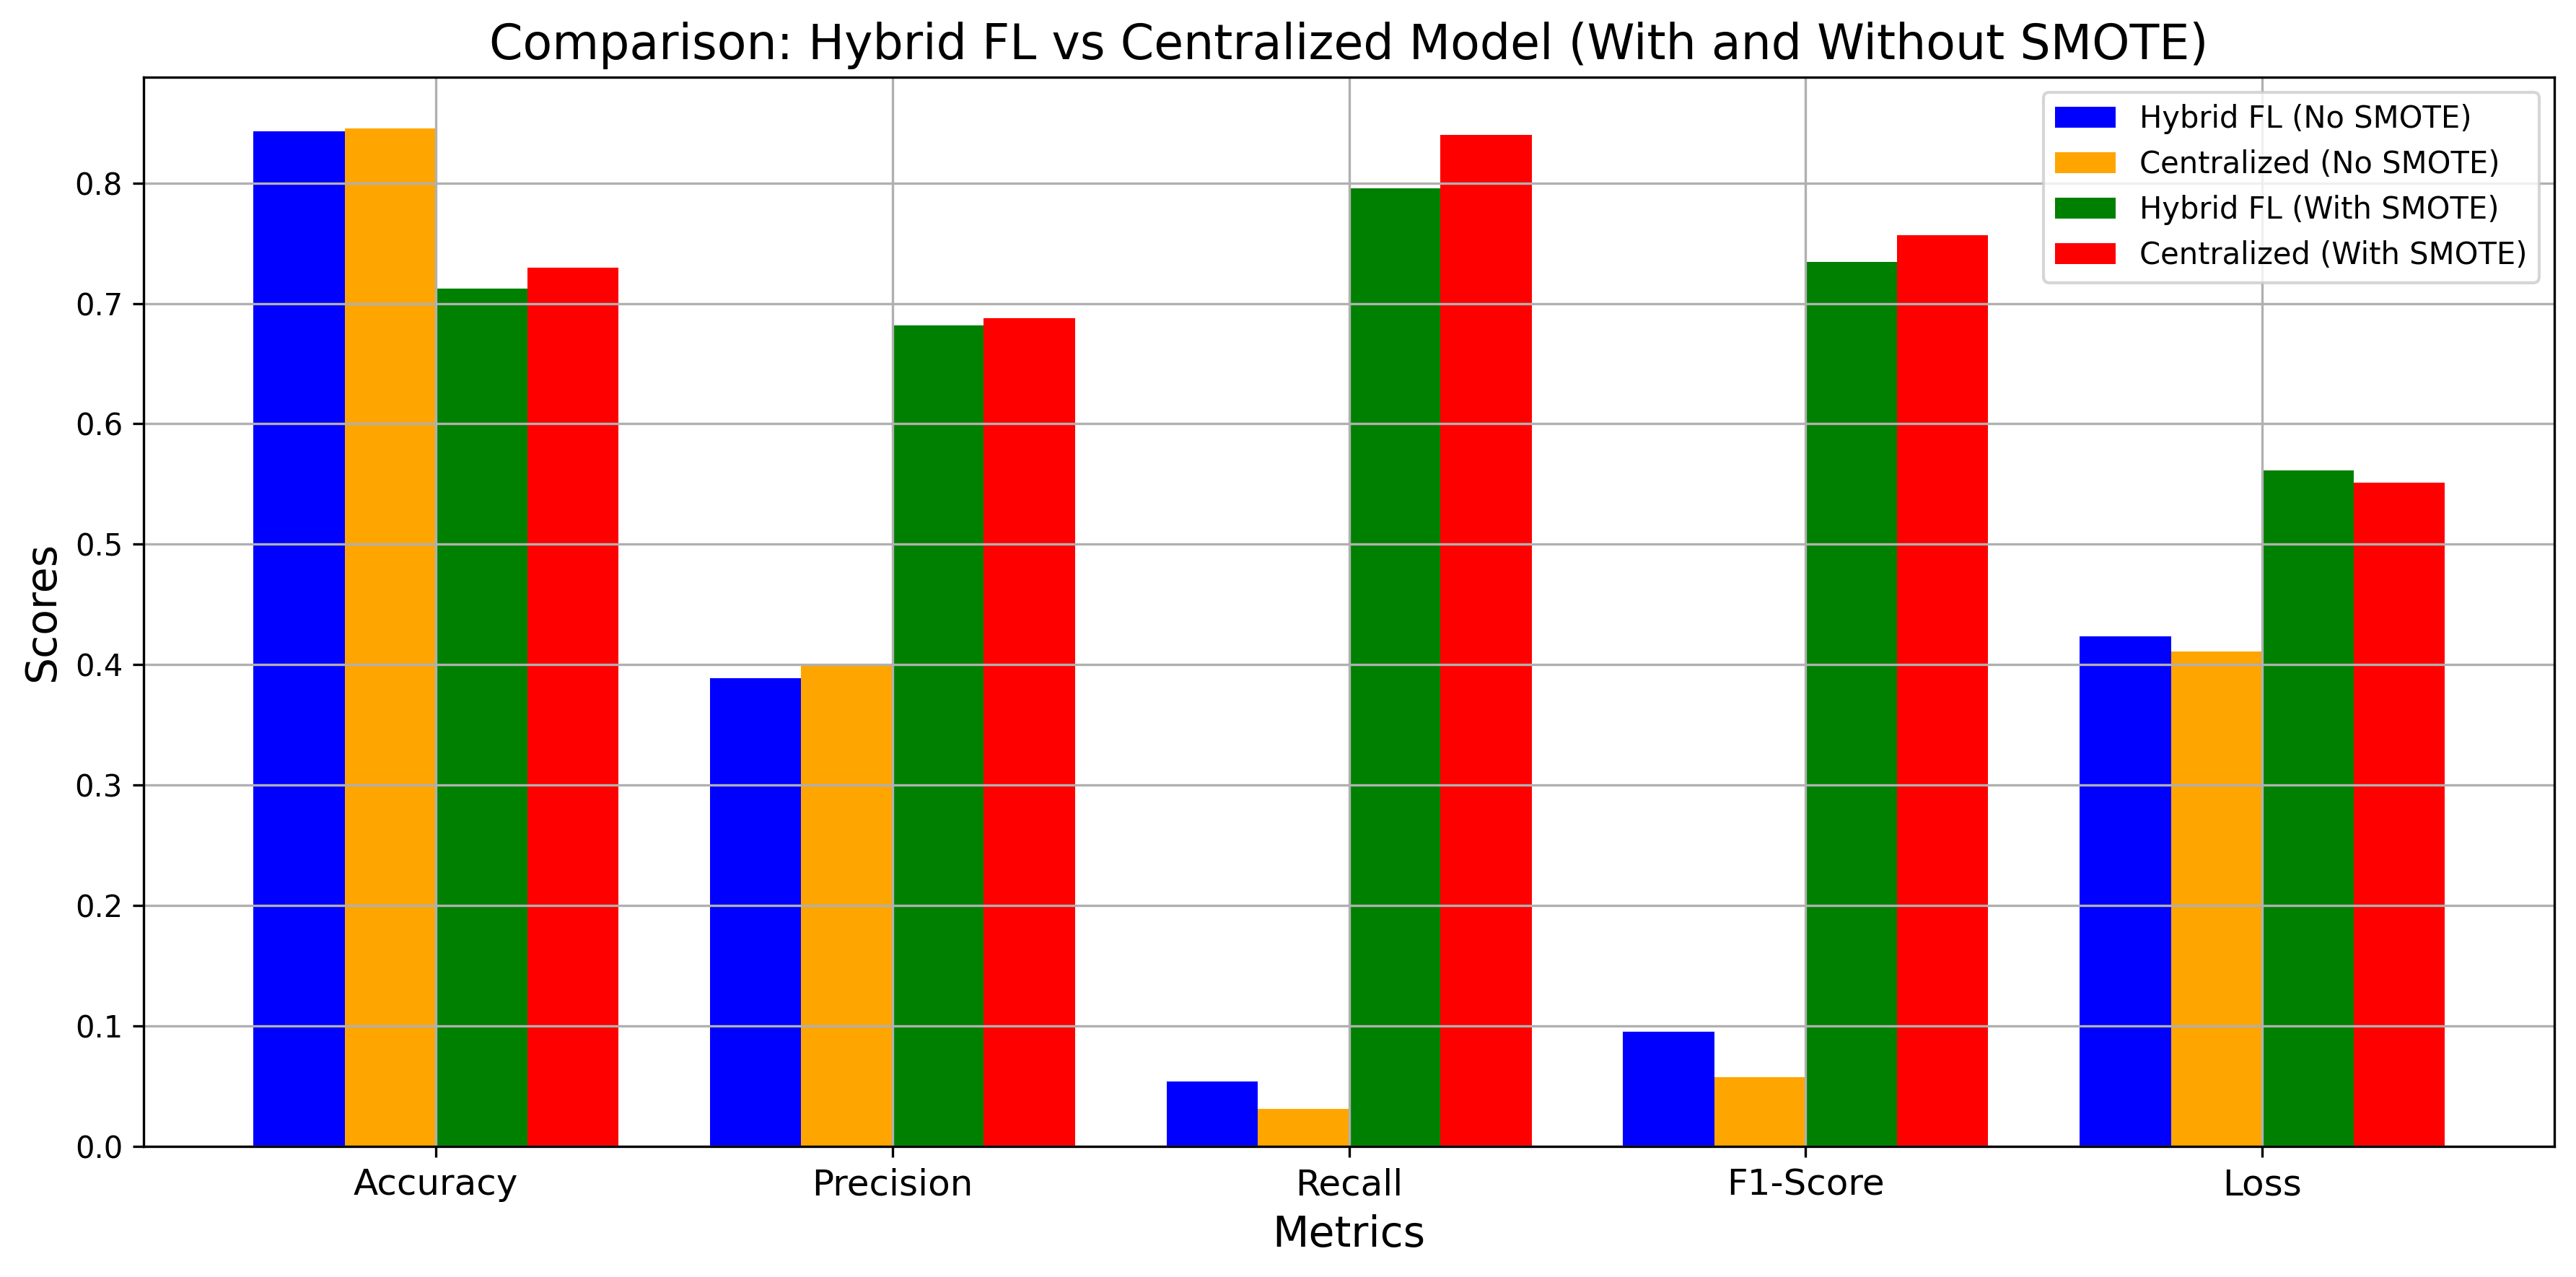

In [ ]:
# 📦 Install necessary libraries
!pip install tensorflow_federated --quiet
!pip install imbalanced-learn --quiet
!pip install --upgrade scipy==1.10.1 --quiet

# 📚 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_federated as tff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from google.colab import files
import random

# 🔁 Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# 📥 Upload and load dataset
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
df = pd.read_csv(file_path)

target_column = 'TenYearCHD'

# 🧠 Define model function
def create_model():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

# 🛠️ Function to run FL and centralized training
def run_experiment(X_data, y_data, use_smote=False):
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, stratify=y_data, random_state=42)

    df_train = pd.DataFrame(X_train, columns=[f"feature_{i}" for i in range(X_train.shape[1])])
    df_train[target_column] = y_train

    # Create 3 clients
    subset_1 = df_train.sample(frac=0.33, random_state=1)
    remaining = df_train.drop(subset_1.index)
    subset_2 = remaining.sample(frac=0.5, random_state=2)
    subset_3 = remaining.drop(subset_2.index)

    clients = [subset_1, subset_2, subset_3]

    def preprocess(dataset):
        X = dataset.drop(columns=[target_column]).values.astype(np.float32)
        y = dataset[target_column].values.astype(np.int32)
        return tf.data.Dataset.from_tensor_slices((X, y)).batch(len(dataset))

    client_data = [preprocess(client) for client in clients]

    # Federated Model
    def model_fn():
        keras_model = create_model()
        keras_model.build(input_shape=(None, X_train.shape[1]))
        input_spec = client_data[0].element_spec
        return tff.learning.models.from_keras_model(
            keras_model,
            input_spec=input_spec,
            loss=tf.keras.losses.BinaryCrossentropy(),
            metrics=[tf.keras.metrics.BinaryAccuracy()]
        )

    from tensorflow_federated.python.learning.algorithms import build_weighted_fed_avg
    iterative_process = build_weighted_fed_avg(
        model_fn,
        client_optimizer_fn=lambda: tf.keras.optimizers.Adam(0.0005),
        server_optimizer_fn=lambda: tf.keras.optimizers.Adam(0.002)
    )

    state = iterative_process.initialize()
    NUM_ROUNDS = 250
    CLIENTS_PER_ROUND = 2

    for round_num in range(1, NUM_ROUNDS + 1):
        selected_ids = random.sample(range(3), CLIENTS_PER_ROUND)
        selected_clients = [client_data[i] for i in selected_ids]
        state, metrics = iterative_process.next(state, selected_clients)

    # 🌍 Train final FL global model
    final_model = create_model()
    final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    final_model.fit(X_train, y_train, epochs=10, verbose=0)
    y_pred = (final_model.predict(X_test) > 0.5).astype(int).flatten()

    fl_acc = accuracy_score(y_test, y_pred)
    fl_prec = precision_score(y_test, y_pred)
    fl_rec = recall_score(y_test, y_pred)
    fl_f1 = f1_score(y_test, y_pred)
    fl_loss = final_model.evaluate(X_test, y_test, verbose=0)[0]

    # 🏁 Centralized training
    centralized_model = create_model()
    centralized_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    centralized_model.fit(X_train, y_train, epochs=10, verbose=0)
    y_pred_cen = (centralized_model.predict(X_test) > 0.5).astype(int).flatten()

    cen_acc = accuracy_score(y_test, y_pred_cen)
    cen_prec = precision_score(y_test, y_pred_cen)
    cen_rec = recall_score(y_test, y_pred_cen)
    cen_f1 = f1_score(y_test, y_pred_cen)
    cen_loss = centralized_model.evaluate(X_test, y_test, verbose=0)[0]

    # 📦 Return results
    return {
        'Hybrid_FL': [fl_acc, fl_prec, fl_rec, fl_f1, fl_loss],
        'Centralized': [cen_acc, cen_prec, cen_rec, cen_f1, cen_loss]
    }

# ⚡ Step 1: Run WITHOUT SMOTE
print("\n⚡ Running Experiment WITHOUT SMOTE...\n")
df.fillna(df.mean(), inplace=True)
X = df.drop(columns=[target_column])
y = df[target_column]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

results_without_smote = run_experiment(X_scaled, y)

# ⚡ Step 2: Run WITH SMOTE
print("\n⚡ Running Experiment WITH SMOTE...\n")
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_scaled, y)

results_with_smote = run_experiment(X_bal, y_bal)

# 🚀 Step 3: Combined Results Plotting
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Loss']

hybrid_fl_without_smote = results_without_smote['Hybrid_FL']
centralized_without_smote = results_without_smote['Centralized']
hybrid_fl_with_smote = results_with_smote['Hybrid_FL']
centralized_with_smote = results_with_smote['Centralized']

x = np.arange(len(metrics_labels))
width = 0.2  # bar width

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

rects1 = ax.bar(x - width*1.5, hybrid_fl_without_smote, width, label='Hybrid FL (No SMOTE)', color='blue')
rects2 = ax.bar(x - width/2, centralized_without_smote, width, label='Centralized (No SMOTE)', color='orange')
rects3 = ax.bar(x + width/2, hybrid_fl_with_smote, width, label='Hybrid FL (With SMOTE)', color='green')
rects4 = ax.bar(x + width*1.5, centralized_with_smote, width, label='Centralized (With SMOTE)', color='red')

ax.set_xlabel('Metrics', fontsize=14)
ax.set_ylabel('Scores', fontsize=14)
ax.set_title('Comparison: Hybrid FL vs Centralized Model (With and Without SMOTE)', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('combined_results_comparison.png')
plt.show()


  Using cached tensorflow-2.19.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached tensorflow_federated-0.87.0-py3-none-manylinux_2_31_x86_64.whl.metadata (19 kB)
  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.9.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached numpy-2.1.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached ml_dtypes-0.5.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (21 kB)
INFO: pip is looking at multiple versions of tensorflow-federated to determine which version is compatible with other requirements. This could take a while.
  Using cached tensorflow_federated-0.86.0-py3-none-manylinux_2_31_x86_64.whl.metadata (19 kB)
  Using cached tensorflow_federated-0.85.0-py3-none-manylinux_2_31_x86_64.whl.metadata (19 kB)
  Us

Saving framingham.csv to framingham (5).csv

🔍 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  


/usr/local/lib/python3.11/dist-packages/tensorflow_federated/python/learning/models/keras_utils.py:201: UserWarning: Batch Normalization contains non-trainable variables that won't be updated during the training. Consider using Group Normalization instead.
  warnings.warn(



📢 Round 1 Completed
   - Client 1 Accuracy: 0.0000, Loss: 0.0000
   - Client 2 Accuracy: 0.5558, Loss: 0.8892
   - Client 3 Accuracy: 0.5558, Loss: 0.8892
--------------------------------------------------

📢 Round 2 Completed
   - Client 1 Accuracy: 0.5701, Loss: 0.8481
   - Client 2 Accuracy: 0.5701, Loss: 0.8481
   - Client 3 Accuracy: 0.5558, Loss: 0.8892
--------------------------------------------------

📢 Round 3 Completed
   - Client 1 Accuracy: 0.5805, Loss: 0.8120
   - Client 2 Accuracy: 0.5701, Loss: 0.8481
   - Client 3 Accuracy: 0.5805, Loss: 0.8120
--------------------------------------------------

📢 Round 4 Completed
   - Client 1 Accuracy: 0.5890, Loss: 0.7724
   - Client 2 Accuracy: 0.5701, Loss: 0.8481
   - Client 3 Accuracy: 0.5890, Loss: 0.7724
--------------------------------------------------

📢 Round 5 Completed
   - Client 1 Accuracy: 0.6156, Loss: 0.7499
   - Client 2 Accuracy: 0.5701, Loss: 0.8481
   - Client 3 Accuracy: 0.6156, Loss: 0.7499
----------------

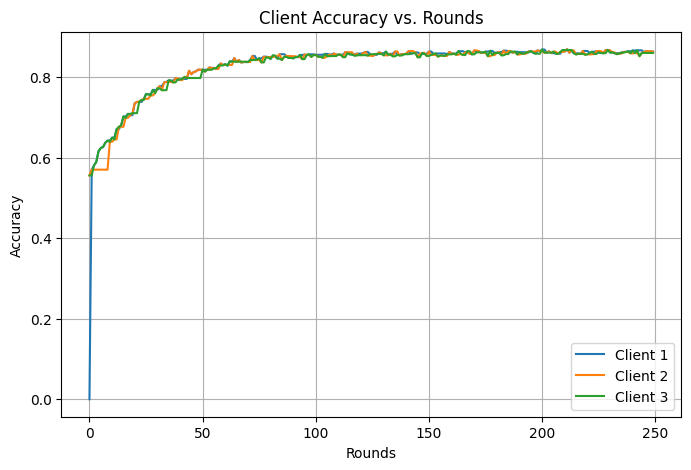

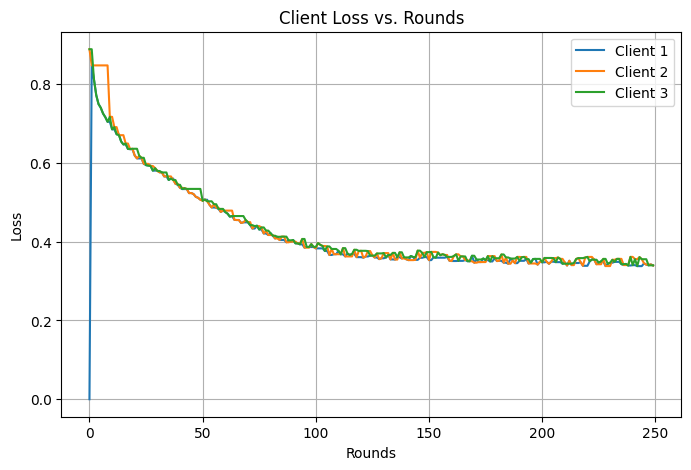

45/45 [==============================] - 0s 2ms/step

🌍 Final Hybrid FL Performance:
   - Accuracy: 0.7241
   - Precision: 0.6998
   - Recall: 0.7844
   - F1 Score: 0.7397
   - Loss: 0.5667


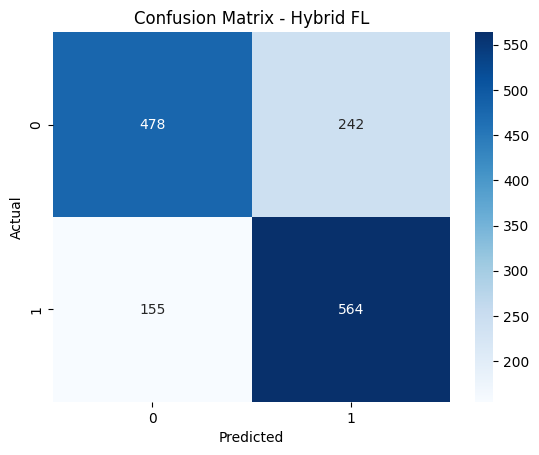

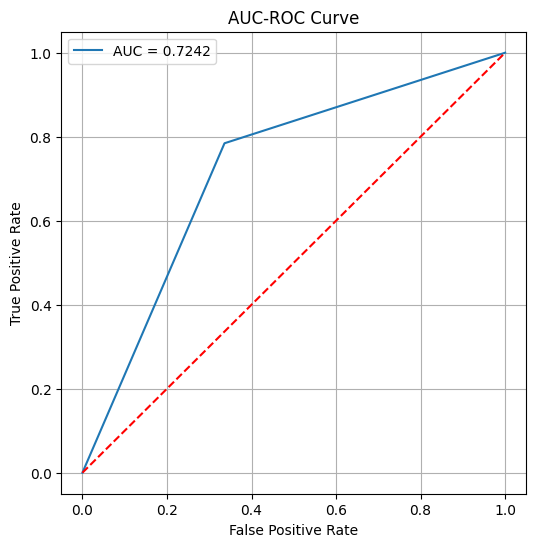


🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.66      0.71       720
           1       0.70      0.78      0.74       719

    accuracy                           0.72      1439
   macro avg       0.73      0.72      0.72      1439
weighted avg       0.73      0.72      0.72      1439

45/45 [==============================] - 0s 3ms/step

📊 Centralized Model Performance:
   - Accuracy: 0.7345
   - Precision: 0.7028
   - Recall: 0.8122
   - F1-Score: 0.7535
   - Loss: 0.5547


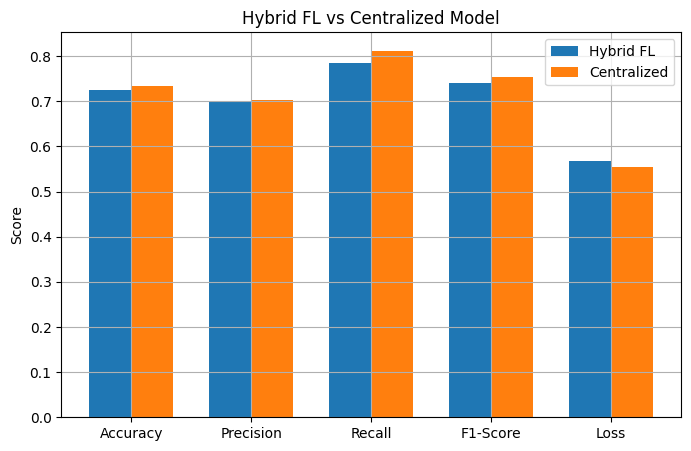

In [ ]:
!pip install --upgrade tensorflow tensorflow-federated pandas numpy matplotlib seaborn scikit-learn


# 📦 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_federated as tff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from google.colab import files
import random

# 📌 Set seed
np.random.seed(42)
tf.random.set_seed(42)

# 📁 Upload & Load
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
df = pd.read_csv(file_path)
target_column = 'TenYearCHD'

# 👁 Overview
print("\n🔍 Dataset Overview:")
print(df.info())
print("\n📊 Original Class Distribution:")
print(df[target_column].value_counts(normalize=True))

# 🧹 Handle Missing
df.fillna(df.mean(), inplace=True)

# 🚀 Feature-Target Split
X = df.drop(columns=[target_column])
y = df[target_column]

# 🔄 Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🧪 SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
print("\n🔄 After SMOTE - Balanced Class Distribution:")
print(pd.Series(y_resampled).value_counts(normalize=True))

# ✂ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# 🧩 Split for FL
subset_1 = df.sample(frac=0.33, random_state=1)
remaining = df.drop(subset_1.index)
subset_2 = remaining.sample(frac=0.5, random_state=2)
subset_3 = remaining.drop(subset_2.index)

def preprocess(dataset, target_column):
    X = dataset.drop(columns=[target_column])
    y = dataset[target_column]
    X_scaled = scaler.transform(X)  # Apply same scaler
    return tf.data.Dataset.from_tensor_slices((X_scaled, y.values)).batch(len(dataset))

client_data = [preprocess(subset_1, target_column),
               preprocess(subset_2, target_column),
               preprocess(subset_3, target_column)]

print("\n✅ Hybrid FL setup completed.")

# 🧠 Model with Batch Norm
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

def model_fn():
    keras_model = create_model()
    input_spec = client_data[0].element_spec
    keras_model.build(input_shape=(None, X_train.shape[1]))
    return tff.learning.models.from_keras_model(
        keras_model,
        input_spec=input_spec,
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.BinaryAccuracy()]
    )

# ⚙ TFF Federated Averaging
from tensorflow_federated.python.learning.algorithms import build_weighted_fed_avg

iterative_process = build_weighted_fed_avg(
    model_fn,
    client_optimizer_fn=lambda: tf.keras.optimizers.Adam(learning_rate=0.0005),
    server_optimizer_fn=lambda: tf.keras.optimizers.Adam(learning_rate=0.002)
)

state = iterative_process.initialize()

# 🔄 Federated Training Loop with Partial Participation
NUM_ROUNDS = 250
client_accuracies = {1: [], 2: [], 3: []}
client_losses = {1: [], 2: [], 3: []}

for round_num in range(1, NUM_ROUNDS + 1):
    participating_clients = random.sample([0, 1, 2], k=2)  # Pick 2 of 3
    selected_client_data = [client_data[i] for i in participating_clients]

    state, metrics = iterative_process.next(state, selected_client_data)

    for i in range(3):
        if i in participating_clients:
            acc = metrics['client_work']['train']['binary_accuracy']
            loss = metrics['client_work']['train']['loss']
        else:
            acc = client_accuracies[i + 1][-1] if client_accuracies[i + 1] else 0
            loss = client_losses[i + 1][-1] if client_losses[i + 1] else 0

        client_accuracies[i + 1].append(acc)
        client_losses[i + 1].append(loss)

    print(f"\n📢 Round {round_num} Completed")
    for i in range(1, 4):
        print(f"   - Client {i} Accuracy: {client_accuracies[i][-1]:.4f}, Loss: {client_losses[i][-1]:.4f}")
    print("--------------------------------------------------")

# 📈 Accuracy Plot
plt.figure(figsize=(8, 5))
for i in range(1, 4):
    plt.plot(client_accuracies[i], label=f'Client {i}')
plt.title('Client Accuracy vs. Rounds')
plt.xlabel('Rounds')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# 📉 Loss Plot
plt.figure(figsize=(8, 5))
for i in range(1, 4):
    plt.plot(client_losses[i], label=f'Client {i}')
plt.title('Client Loss vs. Rounds')
plt.xlabel('Rounds')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# 🌍 Evaluate Final FL Model
final_model = create_model()
final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
final_model.fit(X_train, y_train, epochs=10, verbose=0)

y_pred = (final_model.predict(X_test) > 0.5).astype(int).flatten()
final_global_accuracy = accuracy_score(y_test, y_pred)
final_global_precision = precision_score(y_test, y_pred)
final_global_recall = recall_score(y_test, y_pred)
final_global_f1 = f1_score(y_test, y_pred)
final_global_loss = final_model.evaluate(X_test, y_test, verbose=0)[0]

print("\n🌍 Final Hybrid FL Performance:")
print(f"   - Accuracy: {final_global_accuracy:.4f}")
print(f"   - Precision: {final_global_precision:.4f}")
print(f"   - Recall: {final_global_recall:.4f}")
print(f"   - F1 Score: {final_global_f1:.4f}")
print(f"   - Loss: {final_global_loss:.4f}")

# 📊 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Hybrid FL")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 📈 AUC-ROC
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve")
plt.legend()
plt.grid()
plt.show()

print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred))

# 🧪 Centralized Baseline
def train_centralized_model():
    centralized_model = create_model()
    centralized_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    centralized_model.fit(X_train, y_train, epochs=10, verbose=0)

    y_pred = (centralized_model.predict(X_test) > 0.5).astype(int).flatten()
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    loss = centralized_model.evaluate(X_test, y_test, verbose=0)[0]

    return centralized_model, accuracy, precision, recall, f1, loss

centralized_model, centralized_accuracy, centralized_precision, centralized_recall, centralized_f1, centralized_loss = train_centralized_model()

print("\n📊 Centralized Model Performance:")
print(f"   - Accuracy: {centralized_accuracy:.4f}")
print(f"   - Precision: {centralized_precision:.4f}")
print(f"   - Recall: {centralized_recall:.4f}")
print(f"   - F1-Score: {centralized_f1:.4f}")
print(f"   - Loss: {centralized_loss:.4f}")

# 📊 Comparison Plot
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Loss']
hybrid_fl_metrics = [final_global_accuracy, final_global_precision, final_global_recall, final_global_f1, final_global_loss]
centralized_metrics = [centralized_accuracy, centralized_precision, centralized_recall, centralized_f1, centralized_loss]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, hybrid_fl_metrics, width, label='Hybrid FL')
rects2 = ax.bar(x + width/2, centralized_metrics, width, label='Centralized')

ax.set_ylabel('Score')
ax.set_title('Hybrid FL vs Centralized Model')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.grid()
plt.show()


📋 Support Vector Machine Performance:
   - Accuracy: 0.7276
   - Precision: 0.7177
   - Recall: 0.7497
   - F1-Score: 0.7333
   - Loss: 0.5507

📋 Random Forest Performance:
   - Accuracy: 0.8999
   - Precision: 0.9021
   - Recall: 0.8971
   - F1-Score: 0.8996
   - Loss: 0.3203

📋 Logistic Regression Performance:
   - Accuracy: 0.6845
   - Precision: 0.6848
   - Recall: 0.6829
   - F1-Score: 0.6838
   - Loss: 0.6074


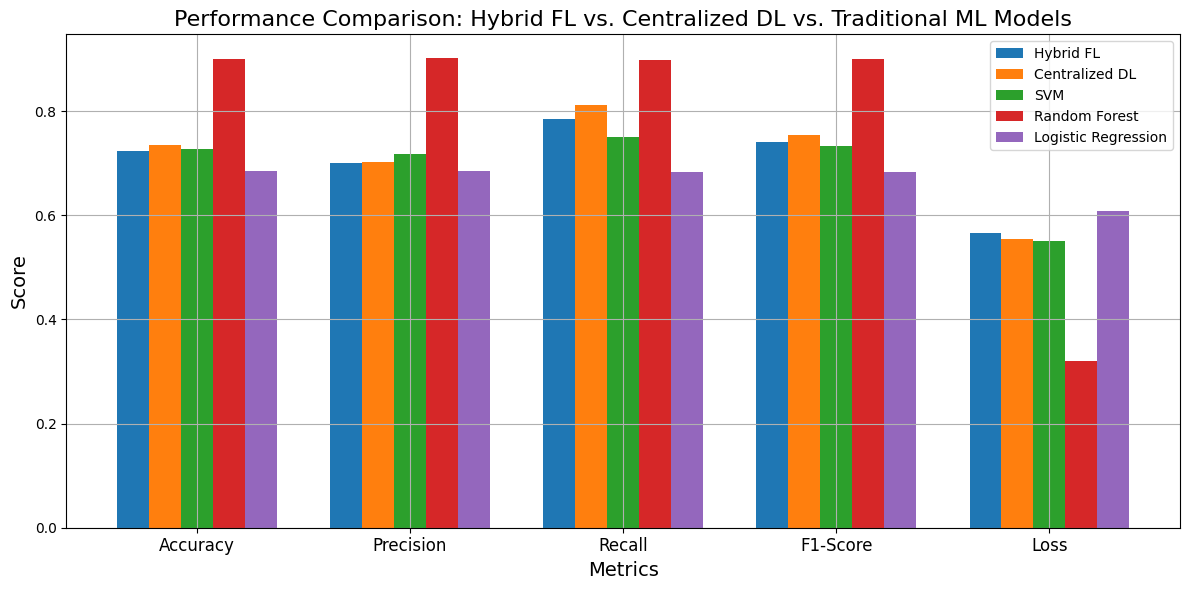

In [ ]:
# 📚 Traditional Machine Learning Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# Train and evaluate traditional ML models
def evaluate_ml_model(model, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    loss = log_loss(y_test, y_pred_prob)

    print(f"\n📋 {model_name} Performance:")
    print(f"   - Accuracy: {acc:.4f}")
    print(f"   - Precision: {prec:.4f}")
    print(f"   - Recall: {rec:.4f}")
    print(f"   - F1-Score: {f1:.4f}")
    print(f"   - Loss: {loss:.4f}")

    return [acc, prec, rec, f1, loss]

# Evaluate SVM
svm_model = SVC(probability=True, random_state=42)
svm_metrics = evaluate_ml_model(svm_model, "Support Vector Machine")

# Evaluate Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_metrics = evaluate_ml_model(rf_model, "Random Forest")

# Evaluate Logistic Regression
lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_metrics = evaluate_ml_model(lr_model, "Logistic Regression")

# 📊 Final Comparison Plot
all_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Loss']

# Already available from your previous code
hybrid_fl_metrics = [final_global_accuracy, final_global_precision, final_global_recall, final_global_f1, final_global_loss]
centralized_metrics = [centralized_accuracy, centralized_precision, centralized_recall, centralized_f1, centralized_loss]

# Collect all metrics
all_models_metrics = [
    hybrid_fl_metrics,
    centralized_metrics,
    svm_metrics,
    rf_metrics,
    lr_metrics
]

model_names = ['Hybrid FL', 'Centralized DL', 'SVM', 'Random Forest', 'Logistic Regression']

# Plot
x = np.arange(len(all_labels))
width = 0.15

fig, ax = plt.subplots(figsize=(12, 6))

for i, metrics in enumerate(all_models_metrics):
    ax.bar(x + i*width - width*2, metrics, width, label=model_names[i])

ax.set_xlabel('Metrics', fontsize=14)
ax.set_ylabel('Score', fontsize=14)
ax.set_title('Performance Comparison: Hybrid FL vs. Centralized DL vs. Traditional ML Models', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(all_labels, fontsize=12)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()
